In [1]:
from cats.cdataframe   import CDataFrame   # tool for extracting data from root files (made by your local developer, Mason Buchanan)

Welcome to JupyROOT 6.28/10


In [2]:
import matplotlib.pyplot as plt    # Matplotlib is the most common plotting package for Python

#The next line is a 'magic' command (indicated by the '%'). These tend to do useful meta things.
%matplotlib inline
#This one makes plots show up in your notebooks. (Note that you can't put comments after it on the same line!)

import pandas as pd                # Some additional data-handling tools
import numpy as np                 # "Numerical python". You need this to process data efficiently
import glob                        # Might be useful for getting files
import cdms
from rawio.IO import *             # Useful for reading binary files which contain raw pulses
import ROOT

In [3]:
sample_dir = '/project/6049244/share/SimData/DMC_SNOLAB_HV/HV100mm_ER_10keV_0V_releaseV05-03/'

In [6]:
DMCfiles = np.sort(glob.glob(sample_dir + 'DMCOutput_10keV_0V_1Wgamma/HV100mm_10keV_0V_5124????_00000?.root'))
RQfile =np.sort(glob.glob(sample_dir + 'Processed_10keV_0V_1Wgamma_Templates/Submerged/Test_5124????_000000.root'))
noisefile = np.sort(glob.glob(sample_dir + 'Processed_10keV_0V_1Wgamma_Templates/Noise/Test_Filter_5124????_000000.root'))

In [70]:
DMCfiles

array(['/project/6049244/share/SimData/DMC_SNOLAB_HV/HV100mm_ER_10keV_0V_releaseV05-03/DMCOutput_10keV_0V_1Wgamma/HV100mm_10keV_0V_51241008_000000.root',
       '/project/6049244/share/SimData/DMC_SNOLAB_HV/HV100mm_ER_10keV_0V_releaseV05-03/DMCOutput_10keV_0V_1Wgamma/HV100mm_10keV_0V_51241008_000001.root',
       '/project/6049244/share/SimData/DMC_SNOLAB_HV/HV100mm_ER_10keV_0V_releaseV05-03/DMCOutput_10keV_0V_1Wgamma/HV100mm_10keV_0V_51241008_000002.root',
       '/project/6049244/share/SimData/DMC_SNOLAB_HV/HV100mm_ER_10keV_0V_releaseV05-03/DMCOutput_10keV_0V_1Wgamma/HV100mm_10keV_0V_51241008_000003.root',
       '/project/6049244/share/SimData/DMC_SNOLAB_HV/HV100mm_ER_10keV_0V_releaseV05-03/DMCOutput_10keV_0V_1Wgamma/HV100mm_10keV_0V_51241008_000004.root',
       '/project/6049244/share/SimData/DMC_SNOLAB_HV/HV100mm_ER_10keV_0V_releaseV05-03/DMCOutput_10keV_0V_1Wgamma/HV100mm_10keV_0V_51241008_000005.root',
       '/project/6049244/share/SimData/DMC_SNOLAB_HV/HV100mm_ER_10keV_0V_rel

In [9]:
channels = ['PAS1', 'PBS1', 'PCS1', 'PDS1', 'PES1', 'PFS1',
            'PAS2', 'PBS2', 'PCS2', 'PDS2', 'PES2', 'PFS2', 'PT']
RQdata = {}
    
zip14 = CDataFrame("rqDir/zip14", RQfile, friends = [[x+":rqDir/eventTree" for x in RQfile]])
RQdata['EventNumber'] = zip14.Filter('EventCategory==6').AsNumpy(['EventNumber'])['EventNumber']

for i in channels:
    RQdata[i + 'OFamps'] = zip14.Filter('EventCategory==6').AsNumpy([i + 'OFamps'])[i + 'OFamps']
    RQdata[i + 'OFdelay'] = zip14.Filter('EventCategory==6').AsNumpy([i + 'OFdelay'])[i + 'OFdelay']

In [68]:
EventNum = 15
channum = 4

# TESSim information is stored in 'G4SimDir/g4dmcTES' tree in the DMC file. Let's store the 'Trace' field.
g4dmcTES = CDataFrame('G4SimDir/g4dmcTES', DMCfiles)
Trace = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum}').AsNumpy(['Trace'])['Trace']
Trace = np.array([max(i) - i for i in Trace]) # flip traces right-side up

# Let's also store the 'ChanNum' and 'ChanName' fields. These tells us which phonon channel the trace belongs to (both the index chanNum and the name ChanName).
ChanName = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum}').AsNumpy(['ChanName'])['ChanName']
ChanNum  = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum}').AsNumpy(['ChanNum'])['ChanNum']

# Let's also get the starting time of the TES pulse T0 and the width of the timebins BinWidth. We can use this to set up the time array TimeBins in units of microseconds.
T0       = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum}').AsNumpy(['T0'])['T0'][0]
BinWidth = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum}').AsNumpy(['BinWidth'])['BinWidth'][0]
TimeBins = np.arange(T0, T0 + BinWidth * len(Trace[0]), BinWidth) * 1e-3 # ns -> us

In [71]:
# Open the ROOT file
file = ROOT.TFile.Open(noisefile[0])
hist = file.Get(f'zip14/{ChanName[0]}TemplateTime')  # Replace 'histname' with the name of your histogram
# Extract histogram data
n_bins = hist.GetNbinsX()
bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
Template = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
# Close the ROOT file
file.Close()

Text(0, 0.5, 'Amplitude [$\\mathrm{\\mu A}$]')

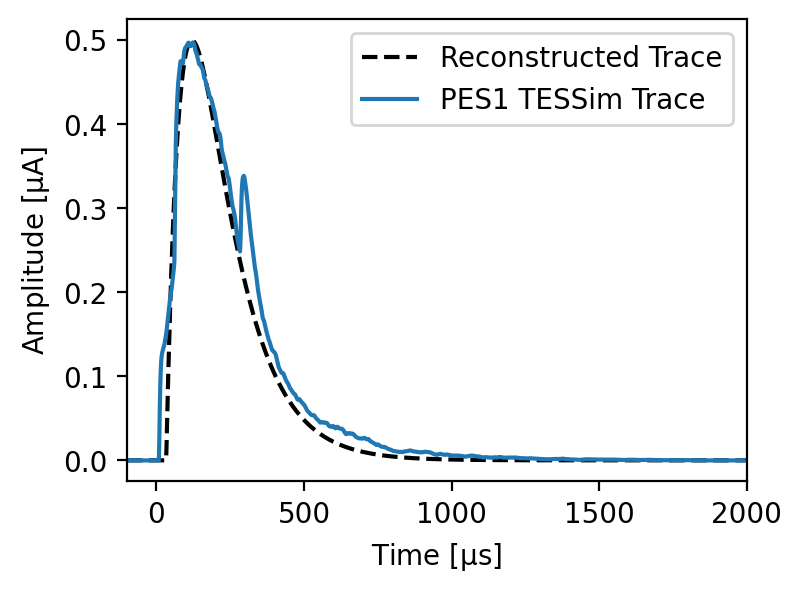

In [73]:
plt.figure(figsize=(4,3), dpi=200)
    
plt.plot(TimeBins + RQdata[f'{ChanName[0]}OFdelay'][EventNum]*1e6, Template*RQdata[f'{ChanName[0]}OFamps'][EventNum]*1e6*10/4, color = 'black', ls = '--', label = 'Reconstructed Trace')
plt.plot(TimeBins, Trace[0], color = 'C0', label = f'{ChanName[0]} TESSim Trace')
    
    
plt.xlim(-100, 2000)
plt.legend()
plt.xlabel(r'Time [$\mathrm{\mu s}$]')
plt.ylabel(r'Amplitude [$\mathrm{\mu A}$]')